In [6]:
import pandas as pd
import matplotlib.pyplot as plt

# Leitura do CSV
df = pd.read_csv("dataset.csv", delimiter=';', decimal=',')

# Conversão de tipos
df["data"] = pd.to_datetime(df["data"], format="%d/%m/%Y")
df["valor"] = df["valor"].astype(float)

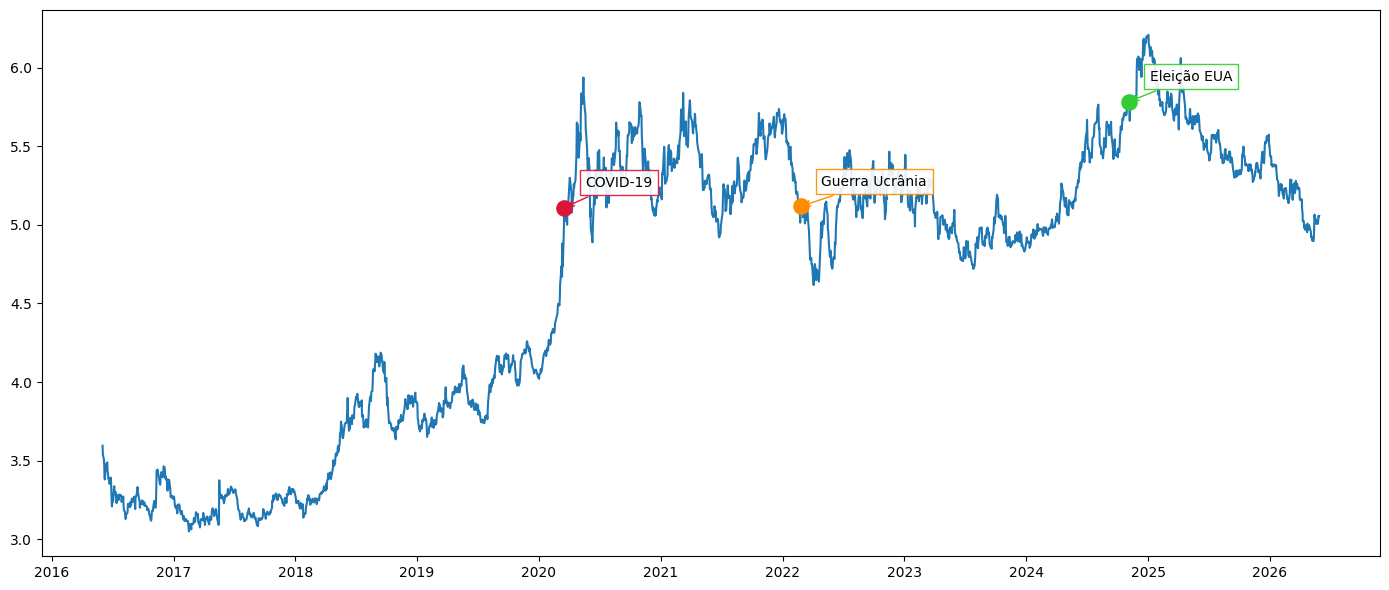

In [27]:
# Plot 1 - Evolução da Cotação do Dólar (USD/BRL) - 2016 a 05/2026
eventos = {
    "2020-03-18": ("COVID-19", "crimson"),
    "2022-02-24": ("Guerra Ucrânia", "darkorange"),
    "2024-11-05": ("Eleição EUA", "limegreen")
}

plt.figure(figsize=(14, 6))

# Série principal
plt.plot(
    df["data"],
    df["valor"],
    linewidth=1.5
)

# Destaques
for data, (descricao, cor) in eventos.items():

    data = pd.Timestamp(data)

    if data in set(df["data"]):
        valor = df.loc[df["data"] == data, "valor"].iloc[0]

        plt.scatter(
            data,
            valor,
            color=cor,
            s=120,
            zorder=5
        )

        plt.annotate(
            descricao,
            (data, valor),
            xytext=(15, 15),
            textcoords="offset points",
            bbox=dict(
                facecolor="white",
                edgecolor=cor,
                alpha=0.9
            ),
            arrowprops=dict(
                arrowstyle="->",
                color=cor
            )
        )

plt.tight_layout()
plt.show()

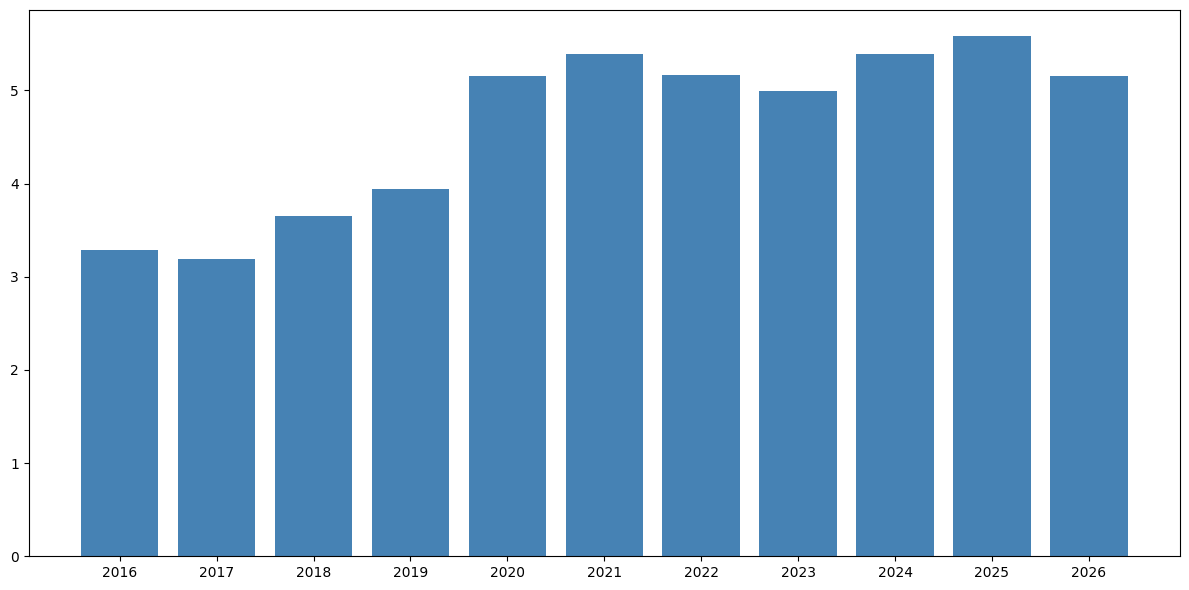

In [ ]:
# Plot 2 - Cotação Média Anual do Dólar (USD/BRL) - 2016 a 05/2026
plt.figure(figsize=(12, 6))

df_ano = (
    df.groupby(df["data"].dt.year)["valor"]
      .mean()
      .reset_index()
)

plt.bar(
    df_ano["data"],
    df_ano["valor"],
    color="steelblue"
)

plt.xticks(df_ano["data"])

plt.tight_layout()
plt.show()

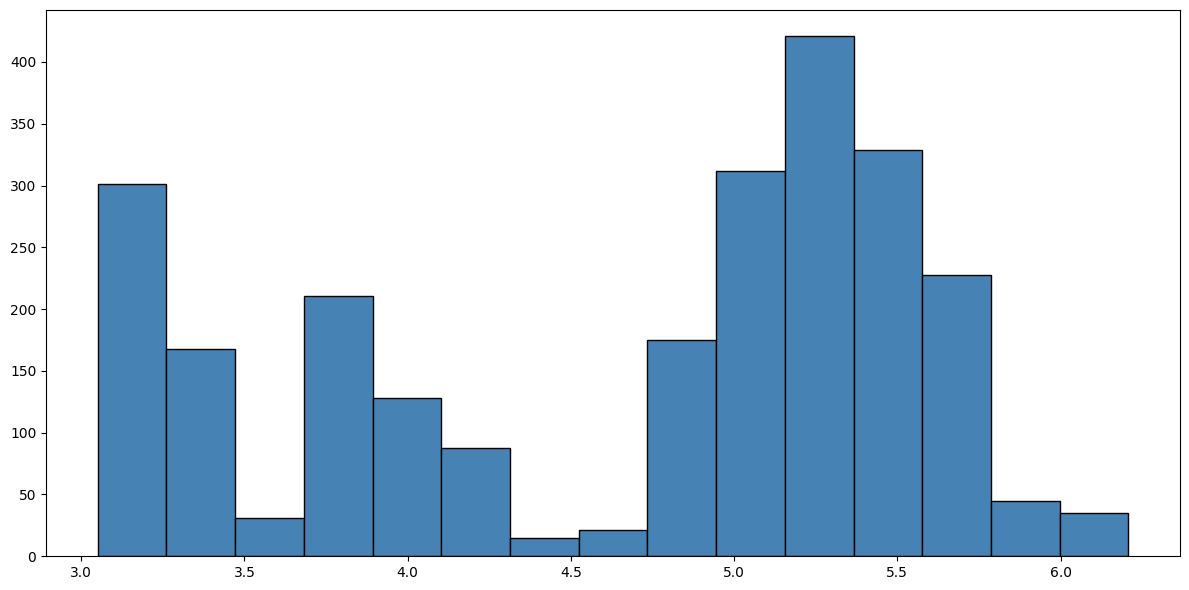

In [ ]:
# Plot 3 - Distribuição das Cotações do Dólar (USD/BRL) - 2016 a 05/2026
plt.figure(figsize=(12, 6))

plt.hist(
    df["valor"],
    bins=15,
    color="steelblue",
    edgecolor="black"
)

plt.tight_layout()
plt.show()